(ch_outliers)=
# Outlier Detection
## Introduction
### What is an Outlier and Why Detect Them?

**Definition**: An outlier is a data point that differs strongly from the majority of the observations in a dataset, according to some chosen notion of distance, density, or typicality.

Such unusual points can arise for many reasons: measurement errors, data-entry mistakes, rare but valid events, genuinely different subgroups, or interesting real-world anomalies. Outliers are important to identify because they can lead to misleading analysis results or indicate interesting phenomena.

**Why should one care?**  
In the context of data science, outliers can skew the results of data analysis, such as mean and standard deviation calculations. They can also affect the performance of machine learning models, leading to less accurate predictions. In some situations, outliers are points that we may want to exclude or treat differently, for example because they arise from data-entry mistakes, broken sensors, or invalid questionnaire responses. In other situations, however, the outliers are exactly what we care about. Think of a large dataset from a questionnaire where many thousands of people gave us answers. When we want to train a model to predict certain properties, we often might want to exclude outliers that could occur from people who did not fill in the questionnaire correctly. Or, we might consider not to "confuse" a model with rare data of a few people who are very different in their answers from the rest of our dataset.

In data science workflows, however, the opposite can happen as well. These are cases where the **outliers are our target data points**. An example of this is cases where we look for unintentional or unwanted behavior, such as fraud in financial transactions or hacker attacks.
This approach has become increasingly important due to the growing number of professional workflows where AI-systems are used to automate key steps (or semi-automate for "human-in-the-loop" systems). Consider, for instance, an industrial production where camera images of produced items are assessed first by an AI. Detecting outliers can here be a way to flag unusual, difficult-to-interpret cases (for the AI), which can then be checked again by a human operator.

### Challenges in Outlier Detection

Detecting outliers is not trivial because it often depends on the context and the nature of the data. The challenge lies in distinguishing between a genuine outlier and a natural variation in the data.
To effectively detect outliers, data scientists must therefore understand the underlying data distribution and choose appropriate methods for outlier identification.

In the following, we will work with some simple, generated data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

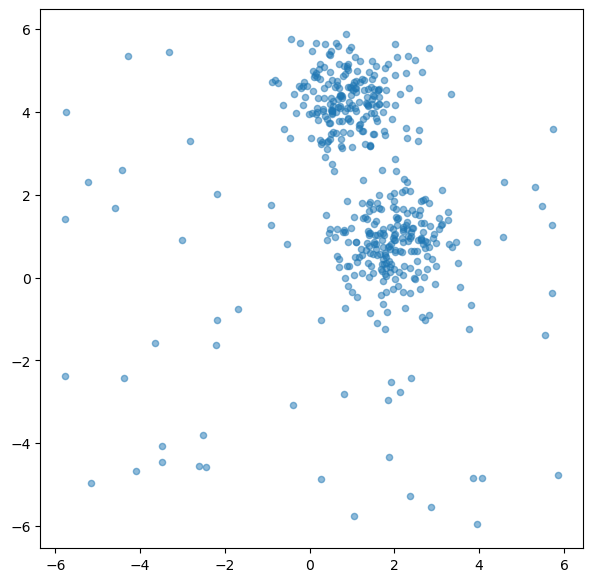

In [2]:
# Create dummy dataset
np.random.seed(0)

# Create toy data: 2 clusters and some additional random data
n_samples = 400
n_noise_samples = 70
clusters = make_blobs(n_samples=n_samples, centers=2, cluster_std=0.70, random_state=0)
random_data = np.random.uniform(low=-6, high=6, size=(n_noise_samples, 2))
X = np.vstack([clusters[0], random_data])

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(X[:, 0], X[:, 1], alpha=0.5, s=20)
plt.show()

Broadly speaking, outlier detection methods often follow two different ideas. Some methods look for points that are unusual with respect to the dataset as a whole. Others ask whether a point looks unusual relative to its local neighborhood. The two methods in this chapter illustrate these perspectives quite well: **Isolation Forest** is more global in spirit, while **LOF** is explicitly local.

## Isolation Forest

### Concept and theory

**Isolation Forest** (often abbreviated as **iForest**) is an unsupervised learning algorithm for anomaly detection. It was introduced in 2008 {cite}`liu2008isolation` and is especially attractive because it works well in many situations where the data may be high-dimensional or where we do not have labeled examples of anomalies.

The key idea behind Isolation Forest is strikingly simple:
**anomalies are usually easier to isolate than normal data points**.

Why is that? In many datasets, normal points occur in relatively dense regions and resemble many other points. To isolate one such point, we usually need a number of splits. Outliers, by contrast, are rare and often lie in unusual parts of the feature space. Because of this, they tend to get separated from the rest of the data much more quickly.

Instead of trying to describe what “normal data” looks like in detail, Isolation Forest takes the opposite route: it repeatedly partitions the data at random and checks how quickly different points become isolated.

To do this, the algorithm builds many random decision trees, called **isolation trees** (or **iTrees**). In each tree, a feature is chosen at random, and then a random split value is selected somewhere between the minimum and maximum value of that feature. Repeating this process creates a sequence of splits that gradually partitions the data into smaller and smaller subsets.

### How the algorithm works

A useful way to think about Isolation Forest is the following:

1. **Build many random trees**
   The algorithm creates many isolation trees. Each tree is grown by repeatedly selecting a random feature and a random split value.

2. **Track how quickly points become isolated**
   For each data point, we can follow the path from the root of a tree down to the point’s final leaf node. This path length tells us how many splits were needed to isolate the point.

3. **Repeat this across many trees**
   A single random tree may isolate a point unusually early or unusually late just by chance. To make the result more stable, the algorithm averages the path lengths over many trees.

4. **Turn path lengths into anomaly scores**
   Points that are isolated after only a few splits receive a high anomaly score. Points that require many splits are considered more normal.

So the basic logic is:

* **short average path length** → probably anomalous
* **long average path length** → probably normal

This is what makes Isolation Forest conceptually elegant. It does not need to estimate a density, draw cluster boundaries, or define what normality looks like explicitly. It simply asks: *how easy is it to isolate this point by random partitioning?*

Because the method uses many random trees rather than a single one, it is also more robust and less sensitive to accidental partitions in any individual tree.

### Implementation in Scikit-Learn


In [3]:
from sklearn.ensemble import IsolationForest

# Create the model
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    n_jobs=-1,
    random_state=42,
    verbose=0)

# Fit the model
iso_forest.fit(X)

# Classify as outlier / no outlier
outlier_classification = iso_forest.predict(X)

**Parameters**:

To learn more about the many different parameters, see the [Scikit-Learn Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html#sklearn.ensemble.IsolationForest).

- `n_estimators`: Number of iTrees in the forest.
- `contamination`: The proportion of outliers in the data set.
- `n_jobs`: The number of jobs to run in parallel.  `None` means no parallel jobs. `-1` means using all processors.
- `random_state`: Controls the randomness of the bootstrapping.

### Plot outlier classification
We can use the isolation forest to predict for each data point if it is an outlier or not. This is binary classification problem, so all data points will be assigned as outliers or inliers.

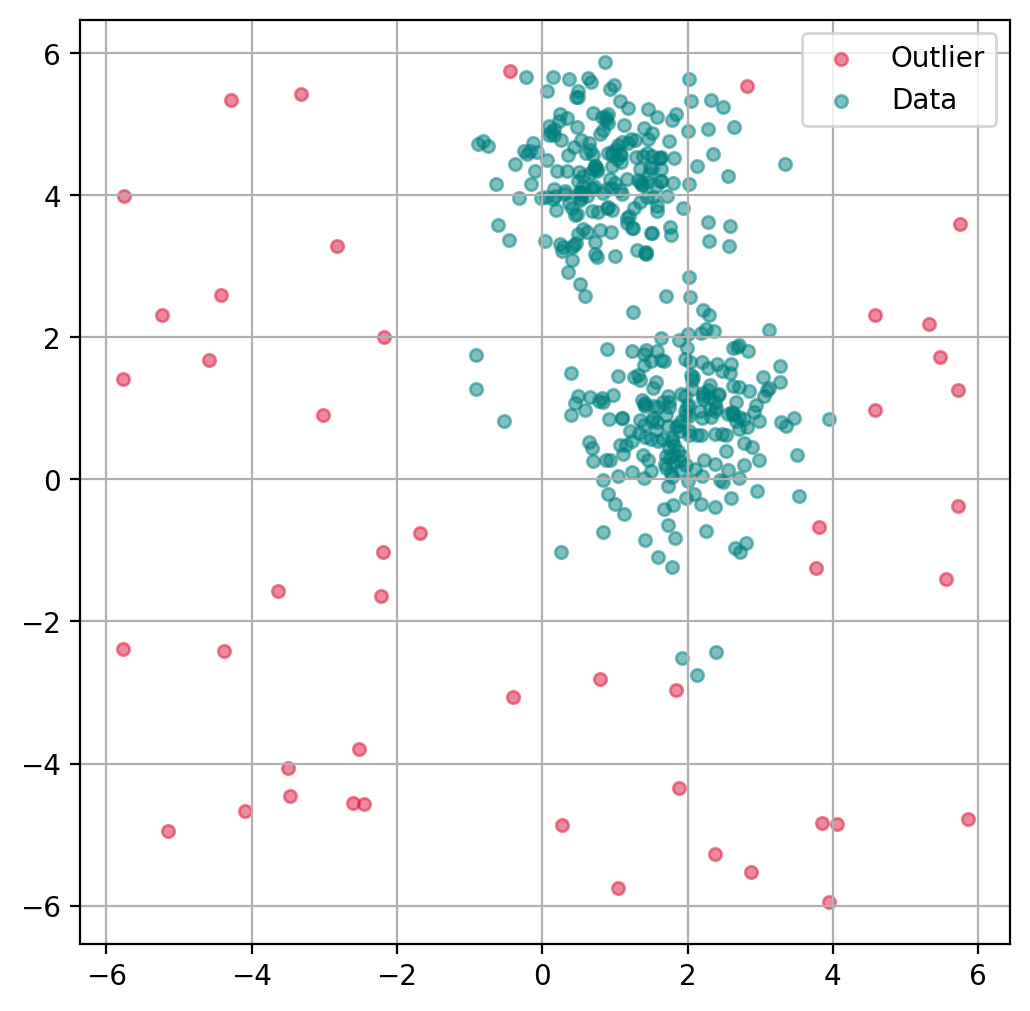

In [4]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=200)

# Scatter Plot: Outlier
mask = outlier_classification == -1
scatter = ax.scatter(X[mask, 0], X[mask, 1],
                     c="crimson",
                     alpha=0.5,
                     label="Outlier",
                     s=20)

# Data
scatter = ax.scatter(X[~mask, 0], X[~mask, 1],
                     c="teal",
                     alpha=0.5,
                     label="Data",
                     s=20)
plt.grid(True)
plt.legend()
plt.show()

### Plot data point "anomaly"
If a binary classification is not what we want, we can also try to use the models decision function to get a somewhat quantitative measure of the "anomaly" of each datapoint.

In [5]:
# Predict degree of anomaly
scores_pred = iso_forest.decision_function(X)

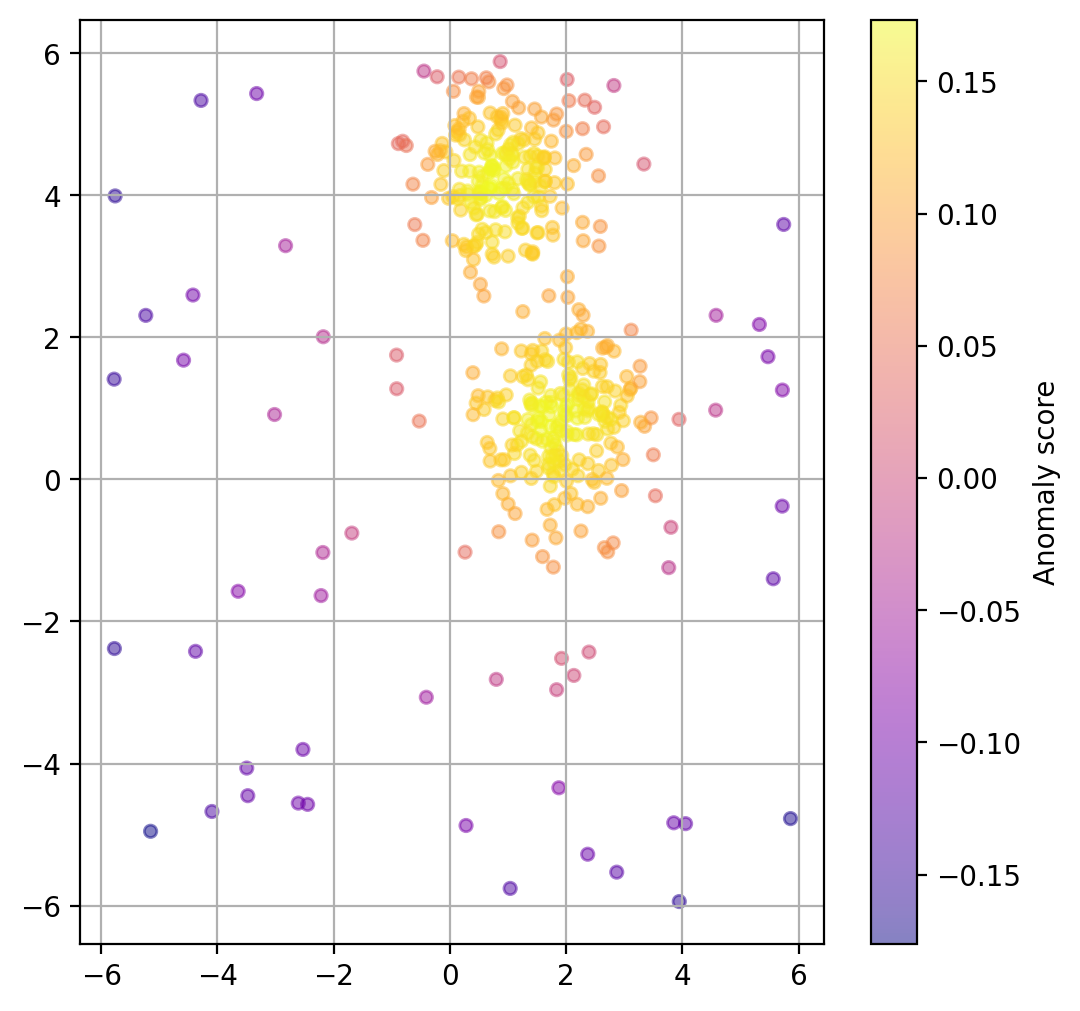

In [6]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=200)
scatter = ax.scatter(
    X[:, 0], X[:, 1],
    c=scores_pred, cmap="plasma",
    alpha=0.5,
    s=20
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Anomaly score")
plt.grid(True)
plt.show()

### Chose how sensitive the outlier detection should be

The parameter `contamination` is used as a threshold for the binary decision into outlier/non-outlier.
The actual underlying anomaly degree is not affected, as the plot below shows.

In [8]:
outlier_classifications = []
anomaly_degrees = []

contaminations = [0.01, 0.1, 0.2, 0.4]
for contamination in contaminations:

    # Create the model
    iso_forest = IsolationForest(
        n_estimators=100,
        contamination=contamination,
        n_jobs=-1,
        random_state=42)

    # Fit the model
    iso_forest.fit(X)

    # Classify as outlier / no outlier
    outlier_classifications.append(iso_forest.predict(X))
    anomaly_degrees.append(iso_forest.decision_function(X))

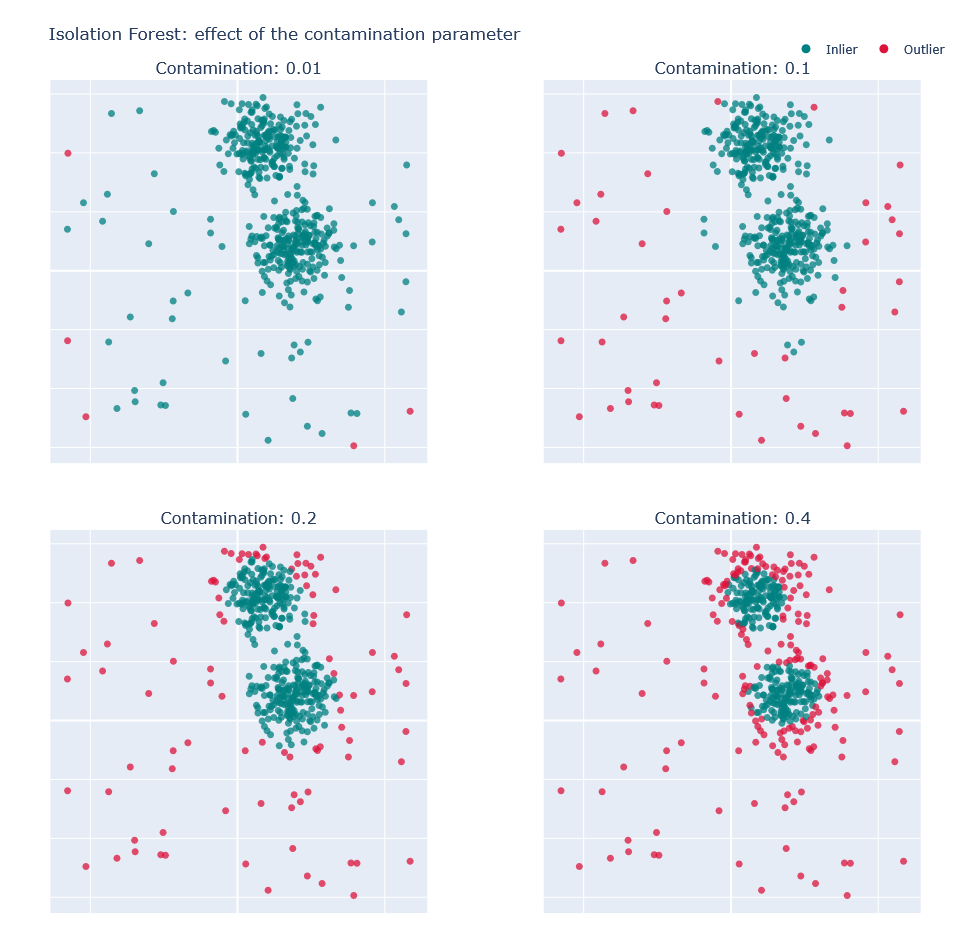

In [19]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Common axis ranges with a little padding
x_min, x_max = X[:, 0].min(), X[:, 0].max()
y_min, y_max = X[:, 1].min(), X[:, 1].max()

x_pad = 0.05 * (x_max - x_min)
y_pad = 0.05 * (y_max - y_min)

x_range = [x_min - x_pad, x_max + x_pad]
y_range = [y_min - y_pad, y_max + y_pad]

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f"Contamination: {c}" for c in contaminations],
    horizontal_spacing=0.06,
    vertical_spacing=0.08
)

color_map = {
    -1: "crimson",   # outlier
     1: "teal"       # inlier
}
label_map = {
    -1: "Outlier",
     1: "Inlier"
}

for idx, contamination in enumerate(contaminations):
    row = idx // 2 + 1
    col = idx % 2 + 1

    classification = outlier_classifications[idx]
    scores = anomaly_degrees[idx]

    colors = [color_map[c] for c in classification]
    labels = [label_map[c] for c in classification]

    hover_text = [
        f"Outlier score: {score:.4f}<br>Classification: {label}"
        for score, label in zip(scores, labels)
    ]

    fig.add_trace(
        go.Scatter(
            x=X[:, 0],
            y=X[:, 1],
            mode="markers",
            marker=dict(
                color=colors,
                size=7,
                opacity=0.75
            ),
            text=hover_text,
            hovertemplate="%{text}<extra></extra>",
            showlegend=False
        ),
        row=row,
        col=col
    )

# Add legend entries once
fig.add_trace(
    go.Scatter(
        x=[None], y=[None],
        mode="markers",
        marker=dict(size=9, color="teal"),
        name="Inlier"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=[None], y=[None],
        mode="markers",
        marker=dict(size=9, color="crimson"),
        name="Outlier"
    ),
    row=1, col=1
)

# Apply identical ranges and equal aspect ratio to all panels
for i in range(1, 5):
    fig.update_xaxes(
        range=x_range,
        showticklabels=False,
        title_text="",
        constrain="domain",
        row=(i - 1) // 2 + 1,
        col=(i - 1) % 2 + 1
    )
    fig.update_yaxes(
        range=y_range,
        showticklabels=False,
        title_text="",
        scaleanchor=f"x{i}",
        scaleratio=1,
        constrain="domain",
        row=(i - 1) // 2 + 1,
        col=(i - 1) % 2 + 1
    )

fig.update_layout(
    title="Isolation Forest: effect of the contamination parameter",
    height=950,
    width=950,
    margin=dict(t=80, l=20, r=20, b=20),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1.0
    )
)

fig.show()

### Advantages

Isolation Forest has several practical advantages that make it a very attractive first method for anomaly detection.

1. **Works well in many high-dimensional settings**
   Because the method does not rely directly on pairwise distance calculations, it often remains useful in higher-dimensional datasets where distance-based methods may become less reliable.

2. **Scales efficiently to larger datasets**
   Isolation Forest is based on tree structures and random partitioning, which makes it computationally efficient and generally well suited for larger datasets.

3. **Does not require labeled anomalies**
   Like many anomaly-detection methods, Isolation Forest is unsupervised. This is especially important in practice, because true anomaly labels are often unavailable, expensive to obtain, or ambiguous.

4. **Provides both scores and binary decisions**
   The method can be used not only to classify points as outliers or inliers, but also to assign an anomaly score. This is useful when we want to rank suspicious cases rather than make a strict yes/no decision immediately.

Overall, Isolation Forest is popular because it combines a fairly intuitive idea with good practical performance. It is often a strong first choice when we want a scalable, unsupervised method for identifying unusual observations.


## Method: Local Outlier Factor (LOF)

### Concept and background

**Local Outlier Factor (LOF)** is an algorithm for detecting **local outliers**, introduced in 2000 {cite}`breunig2000lof`. It is especially useful in datasets where different regions have different densities.

The key idea behind LOF is that a point should not only be judged relative to the whole dataset, but also relative to its **local neighborhood**. A point may look perfectly ordinary from a global perspective and still be highly unusual compared with the points directly around it.

LOF therefore works with the notion of **local density**. For each point, the algorithm looks at its *k* nearest neighbors and compares how densely packed the point’s neighborhood is to the neighborhoods of those neighbors. If a point lies in a region that is much less dense than its surroundings, it may be an outlier.

### How the algorithm works

A useful way to think about LOF is the following:

1. **Find the nearest neighbors**
   For each data point, the algorithm identifies its *k* nearest neighbors. These define the local neighborhood of the point.

2. **Estimate local density**
   The algorithm then estimates how densely the point is surrounded by its neighbors. This is done using a quantity called the **local reachability density (LRD)**. Roughly speaking, this tells us whether a point lies in a tightly packed or loosely packed region.

3. **Compare the point to its neighbors**
   The key step is not just looking at the density of the point itself, but comparing it to the densities of its neighbors.

4. **Compute the LOF score**
   If a point has a much lower local density than its neighbors, its **LOF score** becomes large. Such a point is considered suspicious. Points with LOF values close to 1 are usually considered normal, while points with clearly larger values are more likely to be outliers.

So the core intuition is:

* **similar local density as the neighbors** → probably normal
* **much lower local density than the neighbors** → potentially an outlier

This makes LOF especially powerful in situations where the dataset contains regions of different density. In such cases, a purely global method may miss important local anomalies, while LOF can still flag them because it always asks: *does this point fit well into its immediate surroundings?*

In [10]:
from sklearn.neighbors import LocalOutlierFactor

# Create the model
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.1,
    metric_params=None,
    n_jobs=-1)

# Fit the model and classify outliers
outlier_classification = lof.fit_predict(X)

**Parameters**:

To learn more about the many different parameters, see the [Scikit-Learn Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html#sklearn.neighbors.LocalOutlierFactor).

- `n_neighbors`: Number of neighbors to use.
- `contamination`: The proportion of outliers in the dataset.
- `n_jobs`: Number of parallel jobs to run. `None` means no parallel jobs. `-1` means using all processors.

Here is a smoother rewrite in parallel style to the Isolation Forest section:


### Advantages

Local Outlier Factor has several strengths that make it especially useful in certain anomaly-detection settings.

1. **Works well when densities vary across the dataset**
   LOF is particularly helpful when the data does not have a uniform density. Because it compares each point to its local neighborhood, it can detect outliers even in datasets where different regions are naturally more or less dense.

2. **Flexible with respect to distance measures**
   The method can be combined with different distance metrics, which makes it adaptable to different types of data and feature spaces.

3. **Does not require labeled anomalies**
   Like Isolation Forest, LOF is an unsupervised method. This is very valuable in practice because labeled examples of anomalies are often unavailable or difficult to define reliably.

4. **Especially strong for local anomaly detection**
   LOF is designed to find points that are unusual relative to their immediate surroundings. This makes it particularly useful when an observation may not look extreme globally, but still stands out strongly within its local region.

Overall, Local Outlier Factor is a very useful method when anomalies are best understood in relation to their local neighborhood rather than to the dataset as a whole. This local perspective makes LOF especially valuable for datasets with non-uniform density or more complex local structure.

### Plot outlier classification
Just as with the isolation forest, we can use LOF to predict for each data point if it is an outlier or not.

In [11]:
ax.get_legend_handles_labels()

([], [])

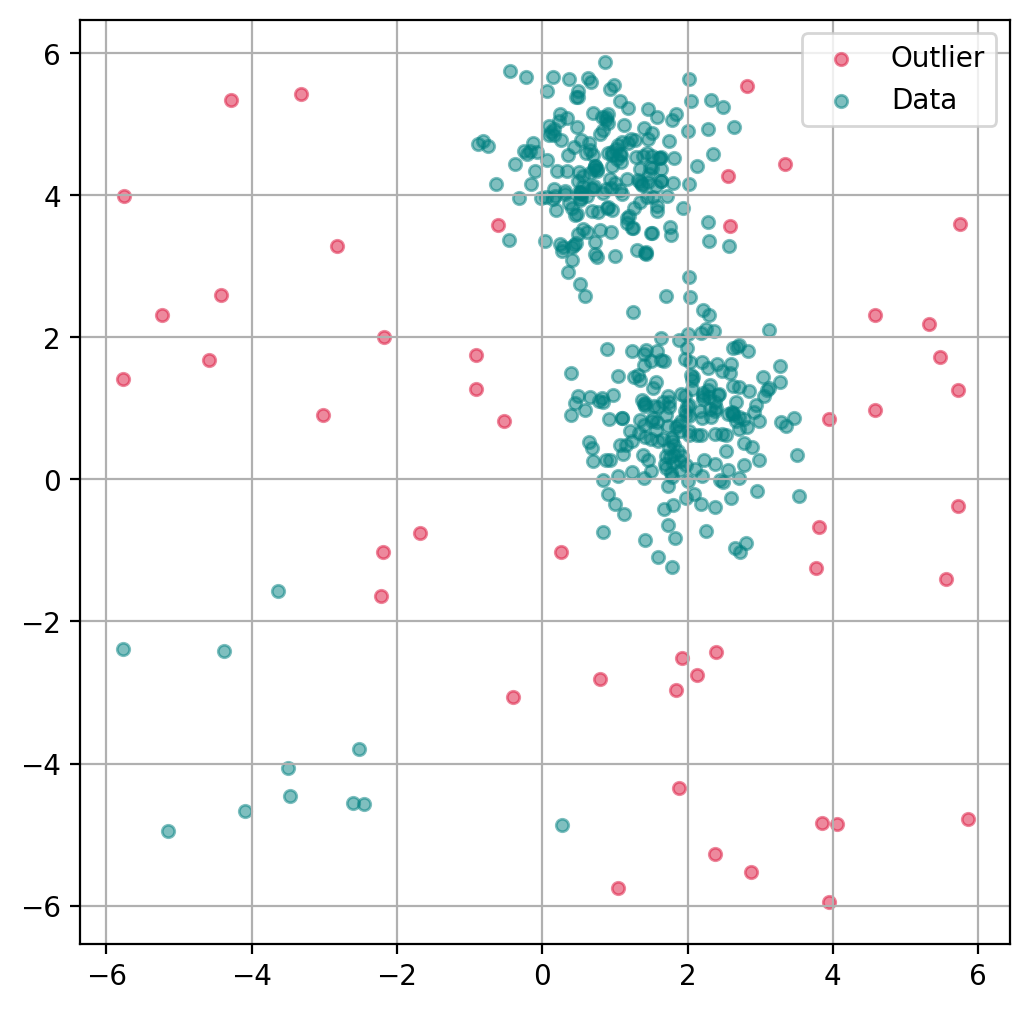

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(6, 6), dpi=200)

# Scatter Plot: Outlier
mask = outlier_classification == -1
scatter = ax.scatter(X[mask, 0], X[mask, 1],
                     c="crimson",
                     alpha=0.5,
                     label="Outlier",
                     s=20)

# Data
scatter = ax.scatter(X[~mask, 0], X[~mask, 1],
                     c="teal",
                     alpha=0.5,
                     label="Data",
                     s=20)
plt.grid(True)
plt.legend()
plt.show()


### Plot data point "anomaly"
If a binary classification is not what we want, we can also try to use the models decision function to get a somewhat quantitative measure of the "anomaly" of each datapoint.

In [13]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.1,
    novelty=True,  # this has to be set to True to later get anomaly ratings
    n_jobs=-1)

lof.fit(X)

# Predict degree of anomaly
anomaly_prediction = lof.decision_function(X)

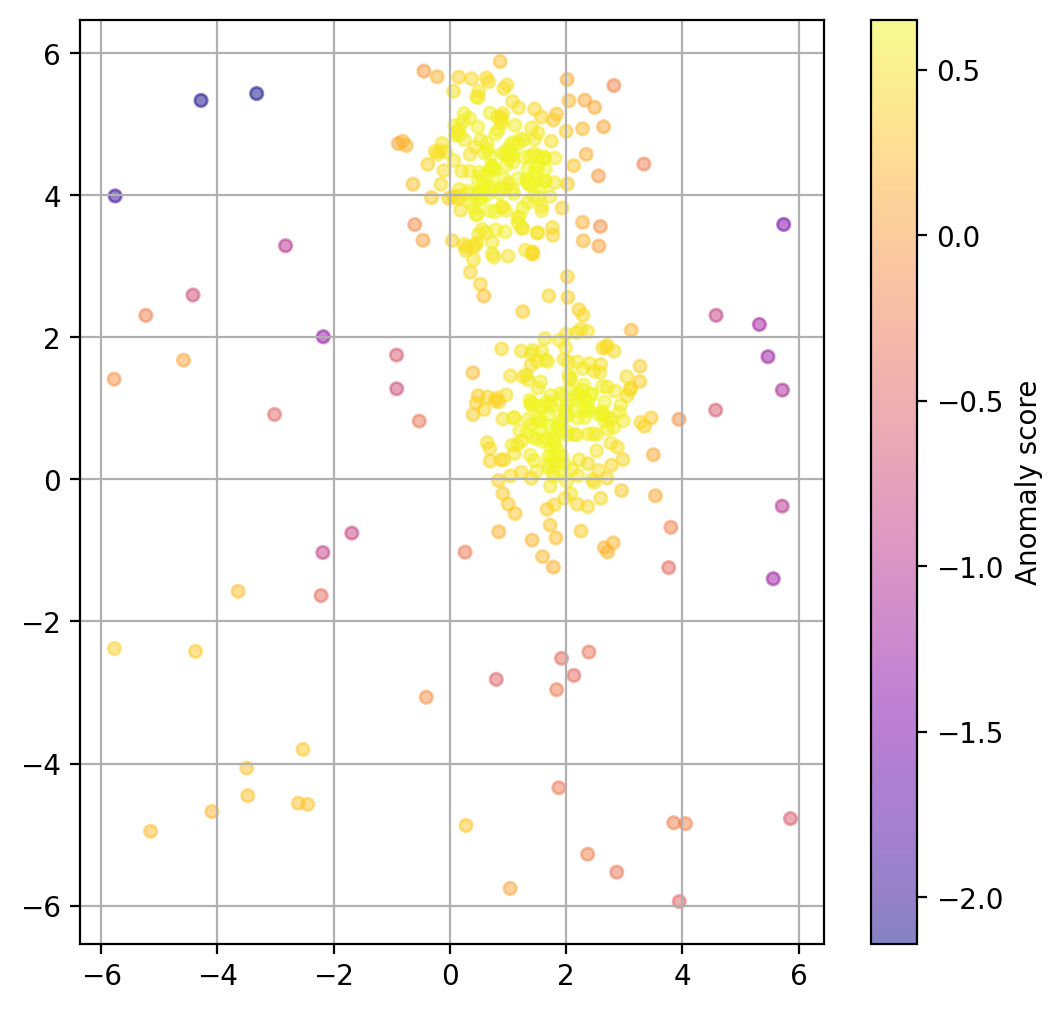

In [14]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=200)
scatter = ax.scatter(
    X[:, 0], X[:, 1],
    c=anomaly_prediction, cmap="plasma",
    alpha=0.5,
    s=20
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Anomaly score")
plt.grid(True)
plt.show()

### Choose how sensitive the outlier detection should be

Here again, we can use the parameter `contamination` to set the threshold for the binary decision into outlier/non-outlier.

In [21]:
outlier_classifications = []
anomaly_degrees = []

contaminations = [0.01, 0.1, 0.2, 0.4]
for contamination in contaminations:

    lof = LocalOutlierFactor(
        n_neighbors=20,
        contamination=contamination,
        novelty=True,  # this has to be set to True to later get anomaly ratings
        n_jobs=-1)

    # Fit the model
    lof.fit(X)

    # Classify as outlier / no outlier
    outlier_classifications.append(lof.predict(X))
    anomaly_degrees.append(lof.decision_function(X))

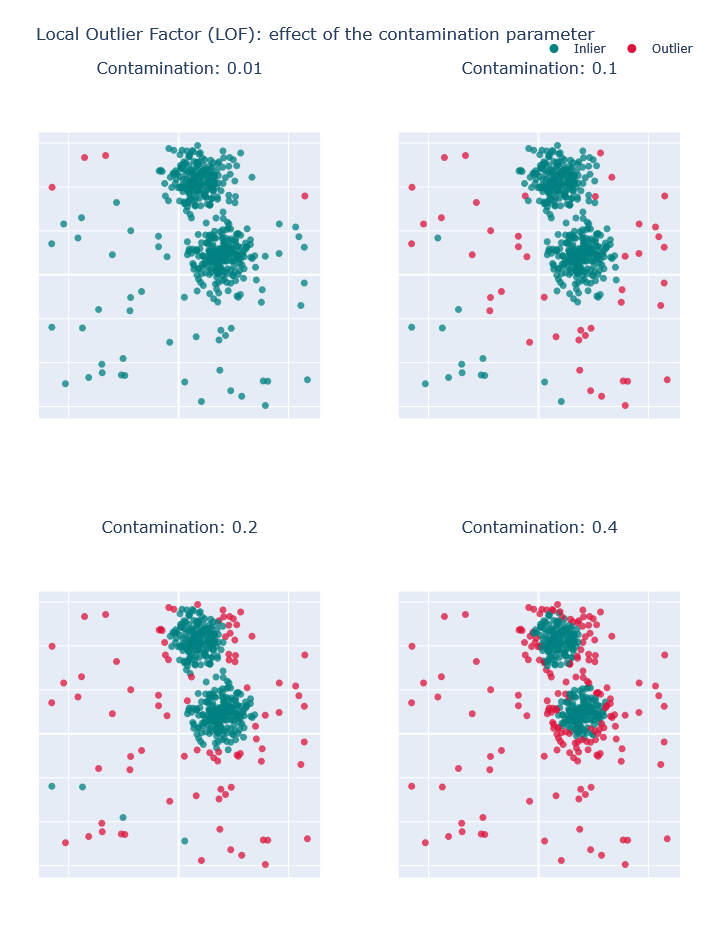

In [22]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Common axis ranges with a little padding
x_min, x_max = X[:, 0].min(), X[:, 0].max()
y_min, y_max = X[:, 1].min(), X[:, 1].max()

x_pad = 0.05 * (x_max - x_min)
y_pad = 0.05 * (y_max - y_min)

x_range = [x_min - x_pad, x_max + x_pad]
y_range = [y_min - y_pad, y_max + y_pad]

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f"Contamination: {c}" for c in contaminations],
    horizontal_spacing=0.06,
    vertical_spacing=0.08
)

color_map = {
    -1: "crimson",   # outlier
     1: "teal"       # inlier
}
label_map = {
    -1: "Outlier",
     1: "Inlier"
}

for idx, contamination in enumerate(contaminations):
    row = idx // 2 + 1
    col = idx % 2 + 1

    classification = outlier_classifications[idx]
    scores = anomaly_degrees[idx]

    colors = [color_map[c] for c in classification]
    labels = [label_map[c] for c in classification]

    hover_text = [
        f"LOF score: {score:.4f}<br>Classification: {label}"
        for score, label in zip(scores, labels)
    ]

    fig.add_trace(
        go.Scatter(
            x=X[:, 0],
            y=X[:, 1],
            mode="markers",
            marker=dict(
                color=colors,
                size=7,
                opacity=0.75
            ),
            text=hover_text,
            hovertemplate="%{text}<extra></extra>",
            showlegend=False
        ),
        row=row,
        col=col
    )

# Add legend entries once
fig.add_trace(
    go.Scatter(
        x=[None], y=[None],
        mode="markers",
        marker=dict(size=9, color="teal"),
        name="Inlier"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=[None], y=[None],
        mode="markers",
        marker=dict(size=9, color="crimson"),
        name="Outlier"
    ),
    row=1, col=1
)

# Apply identical ranges and equal aspect ratio to all panels
for i in range(1, 5):
    fig.update_xaxes(
        range=x_range,
        showticklabels=False,
        title_text="",
        constrain="domain",
        row=(i - 1) // 2 + 1,
        col=(i - 1) % 2 + 1
    )
    fig.update_yaxes(
        range=y_range,
        showticklabels=False,
        title_text="",
        scaleanchor=f"x{i}",
        scaleratio=1,
        constrain="domain",
        row=(i - 1) // 2 + 1,
        col=(i - 1) % 2 + 1
    )

fig.update_layout(
    title="Local Outlier Factor (LOF): effect of the contamination parameter",
    height=950,
    width=950,
    margin=dict(t=80, l=20, r=20, b=20),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1.0
    )
)

fig.show()

## More on Outlier Detection

Outlier detection, or anomaly detection, are often crucial steps in data analysis processes. As a consequence, there are many more techniques for detecting such outliers with varying advantages and disadvantages.

To get a better impression of the rich realm of outlier detection methods, see for instance the following two review articles:
{cite}`boukerche2020outlier`, and {cite}`smiti2020critical`.